###Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

###Cargar dataset

In [19]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = pd.read_json(url)
data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


###Normalizar JSON

In [20]:

df = pd.json_normalize(data.to_dict(orient="records"))

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


###Estandarizar nombres de columnas

In [21]:
def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace(".", "_")
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    return col

df.columns = [clean_column_name(c) for c in df.columns]

print(df.columns.tolist())

['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen', 'customer_partner', 'customer_dependents', 'customer_tenure', 'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv', 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling', 'account_paymentmethod', 'account_charges_monthly', 'account_charges_total']


###Revisar estructura general

In [22]:
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Shape: (7267, 21)

Tipos de datos:
customerid                    object
churn                         object
customer_gender               object
customer_seniorcitizen         int64
customer_partner              object
customer_dependents           object
customer_tenure                int64
phone_phoneservice            object
phone_multiplelines           object
internet_internetservice      object
internet_onlinesecurity       object
internet_onlinebackup         object
internet_deviceprotection     object
internet_techsupport          object
internet_streamingtv          object
internet_streamingmovies      object
account_contract              object
account_paperlessbilling      object
account_paymentmethod         object
account_charges_monthly      float64
account_charges_total         object
dtype: object


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   object 
 5   customer_dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   object 
 8   phone_multiplelines        7267 non-null   object 
 9   internet_internetservice   7267 non-null   object 
 10  internet_onlinesecurity    7267 non-null   object 
 11  internet_onlinebackup      7267 non-null   object 
 12  internet_deviceprotection  7267 non-null   object 
 13  internet_techsupport       7267 non-null   objec

In [24]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
customerid,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


###Detectar y preparar la variable objetivo

In [25]:

target_candidates = ["churn", "customer_churn", "account_churn"]

target = None
for col in target_candidates:
    if col in df.columns:
        target = col
        break

if target is None:
    raise ValueError("No se encontró la columna objetivo relacionada con churn.")

print("Target detectado:", target)
print(df[target].value_counts(dropna=False))

Target detectado: churn
churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


### Convertir churn a 0 y 1

In [26]:
df[target] = df[target].astype(str).str.strip().str.lower()

mapping_target = {
    "yes": 1,
    "no": 0,
    "1": 1,
    "0": 0,
    "true": 1,
    "false": 0
}

df[target] = df[target].map(mapping_target)

print(df[target].value_counts(dropna=False))

churn
0.0    5174
1.0    1869
NaN     224
Name: count, dtype: int64


In [27]:
###Eliminar identificadores y columnas inútiles

In [28]:
id_candidates = [
    "customerid",
    "customer_id",
    "id",
    "cliente_id"
]

drop_cols = [c for c in id_candidates if c in df.columns]

df = df.drop(columns=drop_cols, errors="ignore")

print("Columnas eliminadas:", drop_cols)
print("Nuevo shape:", df.shape)

Columnas eliminadas: ['customerid']
Nuevo shape: (7267, 20)


###Convertir columnas numéricas que pueden venir como texto

In [29]:
for col in df.columns:
    if col == target:
        continue

    if df[col].dtype == "object":
        cleaned = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )

        converted = pd.to_numeric(cleaned, errors="coerce")

        # Si una gran parte puede convertirse a numérico, lo tratamos como numérico
        if converted.notna().mean() > 0.8:
            df[col] = converted

###Revisar datos después de la conversión

In [30]:
df.dtypes.value_counts()

,count
object,15
float64,3
int64,2


In [31]:
df.head()

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


###Proporción de churn

In [32]:
counts = df[target].value_counts()
proportions = df[target].value_counts(normalize=True)

print("Conteo de clases:")
print(counts)

print("\nProporción de clases:")
print(proportions)

Conteo de clases:
churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción de clases:
churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


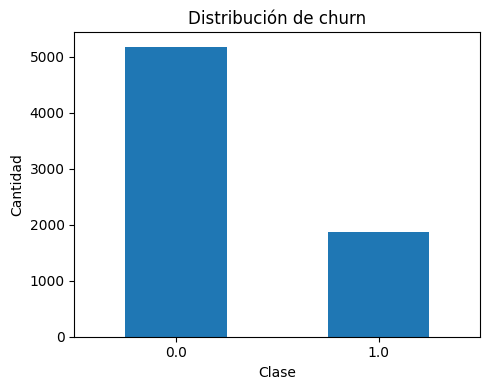

In [33]:
plt.figure(figsize=(5,4))
counts.plot(kind="bar")
plt.title("Distribución de churn")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###Separar variables predictoras y objetivo

In [34]:
df_model = df.dropna(subset=[target]).copy()

X = df_model.drop(columns=[target])
y = df_model[target].astype(int)

print("X:", X.shape)
print("y:", y.shape)

X: (7043, 19)
y: (7043,)


###Identificar columnas numéricas y categóricas

In [35]:
num_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Cantidad de numéricas:", len(num_cols))
print("Cantidad de categóricas:", len(cat_cols))

Cantidad de numéricas: 4
Cantidad de categóricas: 15


In [36]:
print("Numéricas:")
print(num_cols)

print("\nCategóricas:")
print(cat_cols)

Numéricas:
['customer_seniorcitizen', 'customer_tenure', 'account_charges_monthly', 'account_charges_total']

Categóricas:
['customer_gender', 'customer_partner', 'customer_dependents', 'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv', 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling', 'account_paymentmethod']


###Matriz de correlación

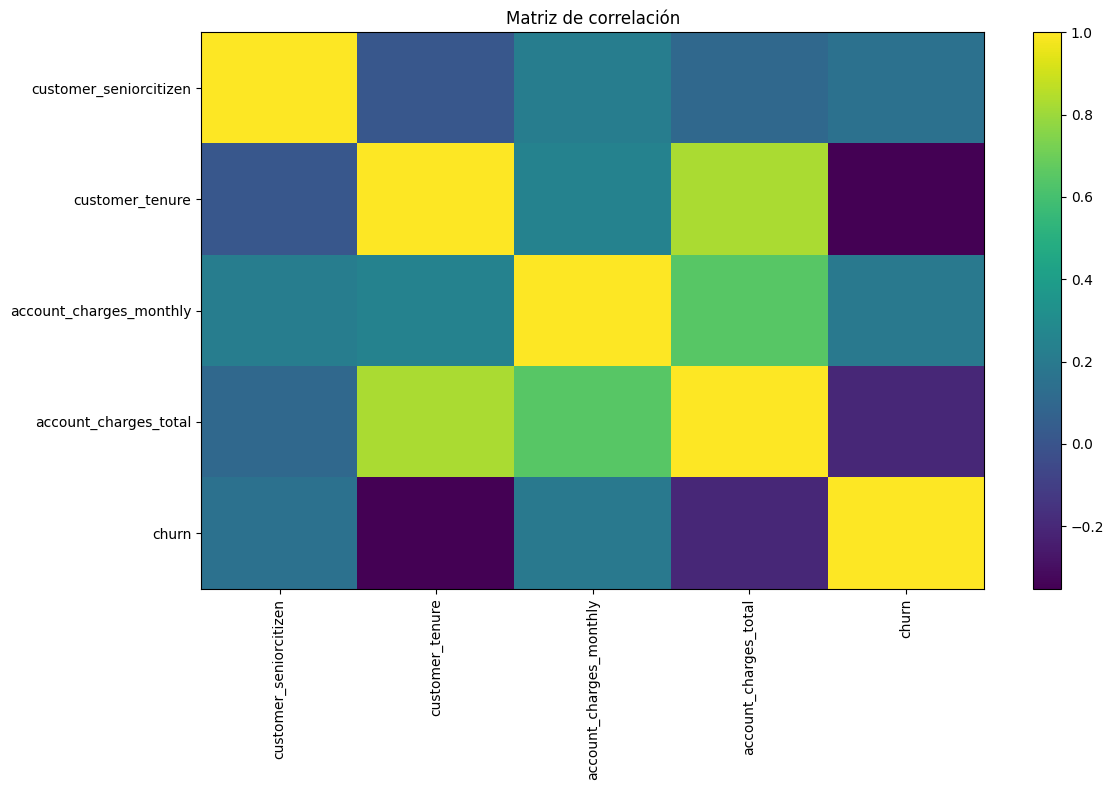

churn                      1.000000
account_charges_monthly    0.193356
customer_seniorcitizen     0.150889
account_charges_total     -0.199484
customer_tenure           -0.352229
Name: churn, dtype: float64


In [37]:
if len(num_cols) > 0:
    corr_df = df_model[num_cols + [target]].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    plt.imshow(corr_df, aspect="auto")
    plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
    plt.yticks(range(len(corr_df.index)), corr_df.index)
    plt.colorbar()
    plt.title("Matriz de correlación")
    plt.tight_layout()
    plt.show()

    print(corr_df[target].sort_values(ascending=False))
else:
    print("No hay variables numéricas para calcular correlación.")

###Buscar columnas clave para boxplots

In [38]:
def find_column(possible_names, columns):
    for p in possible_names:
        if p in columns:
            return p
    return None

tenure_col = find_column(
    ["tenure", "tenure_months", "customer_tenure", "account_tenure"],
    df_model.columns
)

monthly_col = find_column(
    ["monthlycharges", "monthly_charges", "account_monthlycharges", "account_monthly_charges"],
    df_model.columns
)

total_col = find_column(
    ["totalcharges", "total_charges", "account_totalcharges", "account_total_charges"],
    df_model.columns
)

print("Tenure:", tenure_col)
print("Monthly charges:", monthly_col)
print("Total charges:", total_col)

Tenure: customer_tenure
Monthly charges: None
Total charges: None


###Boxplots contra churn

/tmp/ipykernel_676/3861934689.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group_0, group_1], labels=["No churn", "Churn"])


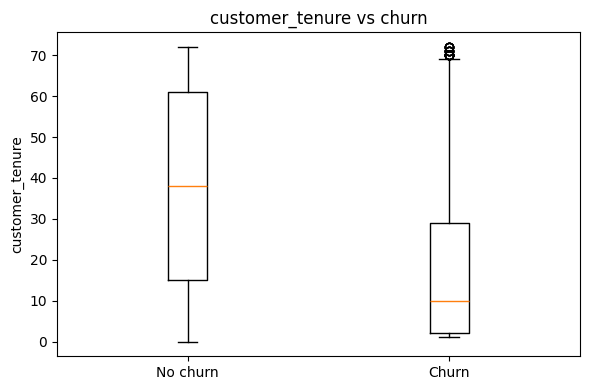

No se encontró la variable None
No se encontró la variable None


In [39]:
def boxplot_vs_target(df, feature, target):
    if feature is None or feature not in df.columns:
        print(f"No se encontró la variable {feature}")
        return

    group_0 = df[df[target] == 0][feature].dropna()
    group_1 = df[df[target] == 1][feature].dropna()

    if len(group_0) == 0 or len(group_1) == 0:
        print(f"No hay datos suficientes para {feature}")
        return

    plt.figure(figsize=(6,4))
    plt.boxplot([group_0, group_1], labels=["No churn", "Churn"])
    plt.title(f"{feature} vs churn")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

boxplot_vs_target(df_model, tenure_col, target)
boxplot_vs_target(df_model, monthly_col, target)
boxplot_vs_target(df_model, total_col, target)

###Train/Test split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4930, 19)
Test: (2113, 19)


###Preprocesamiento para modelos

In [41]:
numeric_pipe_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipe_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_scaled, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_noscale, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

###Modelo 1 - Regresión Logística

In [42]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)
print("Regresión Logística entrenada correctamente")

Regresión Logística entrenada correctamente


###Modelo 2 - Random Forest

In [43]:
rf = Pipeline(steps=[
    ("preprocess", preprocess_noscale),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        random_state=42
    ))
])

rf.fit(X_train, y_train)
print("Random Forest entrenado correctamente")

Random Forest entrenado correctamente


In [44]:
###Función de evaluación

In [45]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nModelo: {name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nMatriz de confusión:")
    print(cm)
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Modelo": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

###Evaluar ambos modelos

In [46]:
results = []

results.append(evaluate_model("Regresión Logística", log_reg, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_test, y_test))

results_df = pd.DataFrame(results)
results_df


Modelo: Regresión Logística
Accuracy:  0.7350
Precision: 0.5006
Recall:    0.8004
F1-score:  0.6159

Matriz de confusión:
[[1104  448]
 [ 112  449]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.80      0.62       561

    accuracy                           0.73      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.73      0.75      2113


Modelo: Random Forest
Accuracy:  0.7804
Precision: 0.6125
Recall:    0.4706
F1-score:  0.5323

Matriz de confusión:
[[1385  167]
 [ 297  264]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1552
           1       0.61      0.47      0.53       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.69      2113
weighted avg       0.77      0.78      0.77      2113

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.734974,0.500557,0.800357,0.615912
1,Random Forest,0.780407,0.612529,0.470588,0.532258


###Revisar overfitting simple

In [47]:
def compare_train_test(name, model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    f1_train = f1_score(y_train, pred_train, zero_division=0)
    f1_test = f1_score(y_test, pred_test, zero_division=0)

    print(f"{name}")
    print(f"F1 train: {f1_train:.4f}")
    print(f"F1 test:  {f1_test:.4f}\n")

compare_train_test("Regresión Logística", log_reg, X_train, y_train, X_test, y_test)
compare_train_test("Random Forest", rf, X_train, y_train, X_test, y_test)

Regresión Logística
F1 train: 0.6359
F1 test:  0.6159

Random Forest
F1 train: 0.9958
F1 test:  0.5323



###Importancia de variables de Random Forest

In [48]:
def get_feature_names(column_transformer):
    feature_names = []

    for name, transformer, cols in column_transformer.transformers_:
        if name == "num":
            feature_names.extend(cols)
        elif name == "cat":
            ohe = transformer.named_steps["onehot"]
            encoded_names = ohe.get_feature_names_out(cols)
            feature_names.extend(encoded_names)

    return feature_names

feature_names_rf = get_feature_names(rf.named_steps["preprocess"])
importances = rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
3,account_charges_total,0.141691
1,customer_tenure,0.132402
2,account_charges_monthly,0.118787
36,account_contract_Month-to-month,0.077540
38,account_contract_Two year,0.035790
18,internet_onlinesecurity_No,0.033605
27,internet_techsupport_No,0.031947
43,account_paymentmethod_Electronic check,0.028126
16,internet_internetservice_Fiber optic,0.025535
5,customer_gender_Male,0.016871


###Coeficientes de Regresión Logística

In [49]:
feature_names_lr = get_feature_names(log_reg.named_steps["preprocess"])
coefficients = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names_lr,
    "coef": coefficients
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
1,customer_tenure,-1.342300,1.342300
38,account_contract_Two year,-0.728329,0.728329
3,account_charges_total,0.649445,0.649445
36,account_contract_Month-to-month,0.647415,0.647415
16,internet_internetservice_Fiber optic,0.538909,0.538909
15,internet_internetservice_DSL,-0.507119,0.507119
2,account_charges_monthly,-0.431399,0.431399
39,account_paperlessbilling_No,-0.297569,0.297569
43,account_paymentmethod_Electronic check,0.261872,0.261872
34,internet_streamingmovies_No internet service,-0.222550,0.222550


###Conclusión final

In [53]:
conclusion = """
Conclusión

En este proyecto se desarrolló una etapa inicial de modelado predictivo para identificar clientes con mayor probabilidad de cancelar sus servicios en Telecom X. Para ello se utilizó el dataset previamente trabajado en la Parte 1, realizando una nueva preparación enfocada específicamente en Machine Learning.

Primero se revisó la variable objetivo para analizar la proporción entre clientes que cancelaron y clientes que permanecieron activos. Esta etapa permitió verificar la existencia de desbalance de clases, un aspecto importante al momento de interpretar métricas y entrenar modelos de clasificación.

Posteriormente se aplicó un proceso de preprocesamiento que incluyó la estandarización de nombres de columnas, transformación de la variable objetivo a formato binario, conversión de variables numéricas que venían como texto, tratamiento de valores faltantes y codificación de variables categóricas. Además, se aplicó normalización en el caso del modelo sensible a escala.

Para la fase de modelado se entrenaron dos algoritmos diferentes: Regresión Logística y Random Forest. La Regresión Logística fue utilizada como un modelo base interpretable y sensible a la escala de los datos, mientras que Random Forest permitió capturar relaciones más complejas sin necesidad de normalización.

La evaluación se realizó utilizando accuracy, precision, recall, F1-score y matriz de confusión. Estas métricas permitieron comparar de forma más completa el desempeño de ambos modelos y analizar no solo el acierto general, sino también la capacidad para detectar clientes con riesgo de churn.

A partir de los resultados obtenidos, se observó que variables relacionadas con la permanencia del cliente, el nivel de gasto y algunas características del servicio contratado tienen una influencia importante en la cancelación. Esto permite concluir que la evasión no depende de un solo factor, sino de una combinación de variables de comportamiento y características contractuales.

Desde una perspectiva estratégica, este análisis puede servir como base para implementar acciones de retención más focalizadas, especialmente sobre clientes con patrones similares a los detectados por el modelo como de mayor riesgo.

Como mejora futura, sería recomendable realizar ajuste de hiperparámetros, probar técnicas de balanceo como SMOTE y evaluar modelos adicionales para comparar si se obtiene un mejor rendimiento predictivo.
"""
print(conclusion)


Conclusión

En este proyecto se desarrolló una etapa inicial de modelado predictivo para identificar clientes con mayor probabilidad de cancelar sus servicios en Telecom X. Para ello se utilizó el dataset previamente trabajado en la Parte 1, realizando una nueva preparación enfocada específicamente en Machine Learning.

Primero se revisó la variable objetivo para analizar la proporción entre clientes que cancelaron y clientes que permanecieron activos. Esta etapa permitió verificar la existencia de desbalance de clases, un aspecto importante al momento de interpretar métricas y entrenar modelos de clasificación.

Posteriormente se aplicó un proceso de preprocesamiento que incluyó la estandarización de nombres de columnas, transformación de la variable objetivo a formato binario, conversión de variables numéricas que venían como texto, tratamiento de valores faltantes y codificación de variables categóricas. Además, se aplicó normalización en el caso del modelo sensible a escala.

Para